# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2


## Definiciones de modelos

In [6]:
# =============================
#   DEFINICIONES DE MODELOS
# =============================

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# --- Data augmentation ---
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

num_classes = 10

# --- Arquitectura CNN 1 ---
def build_cnn1():
    model = models.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- Arquitectura CNN 2 ---
def build_cnn2():
    model = models.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- Arquitectura Transfer Learning: ResNet50 ---
# CIFAR (32x32) → Redimensionar a 224x224
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # congelar capas

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])


## Entrenamiento de modelos.

In [7]:
# =============================
#     ENTRENAMIENTO
# =============================

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Cargar CIFAR-10
(x_train, y_train), (x_val, y_val) = cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0

# Para ResNet50 (aumentar tamaño)
x_train_res = tf.image.resize(x_train, (224,224))
x_val_res = tf.image.resize(x_val, (224,224))

# Crear modelos
cnn1 = build_cnn1()
cnn2 = build_cnn2()

cnn1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_resnet.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Entrenar modelos
history1 = cnn1.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=5)
history2 = cnn2.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=5)
history3 = model_resnet.fit(x_train_res, y_train, validation_data=(x_val_res, y_val), epochs=5)


170498071/170498071 [==============================] - 20s 0us/step

Epoch 1/5


1563/1563 [==============================] - 25s 14ms/step - loss: 1.6301 - accuracy: 0.4076 - val_loss: 1.3440 - val_accuracy: 0.5271
Epoch 2/5
1563/1563 [==============================] - 21s 14ms/step - loss: 1.3773 - accuracy: 0.5091 - val_loss: 1.1912 - val_accuracy: 0.5744
Epoch 3/5
1563/1563 [==============================] - 21s 14ms/step - loss: 1.2879 - accuracy: 0.5419 - val_loss: 1.0843 - val_accuracy: 0.6077
Epoch 4/5
1563/1563 [==============================] - 20s 13ms/step - loss: 1.2288 - accuracy: 0.5611 - val_loss: 1.0576 - val_accuracy: 0.6320
Epoch 5/5
1563/1563 [==============================] - 20s 13ms/step - loss: 1.1915 - accuracy: 0.5791 - val_loss: 1.0663 - val_accuracy: 0.6235
Epoch 1/5
1563/1563 [==============================] - 31s 19ms/step - loss: 1.8647 - accuracy: 0.2876 - val_loss: 1.5758 - val_accuracy: 0.4185
Epoch 2/5
1563/1563 [==============================] - 32s 

KeyboardInterrupt: 

## Estadística y gráficos

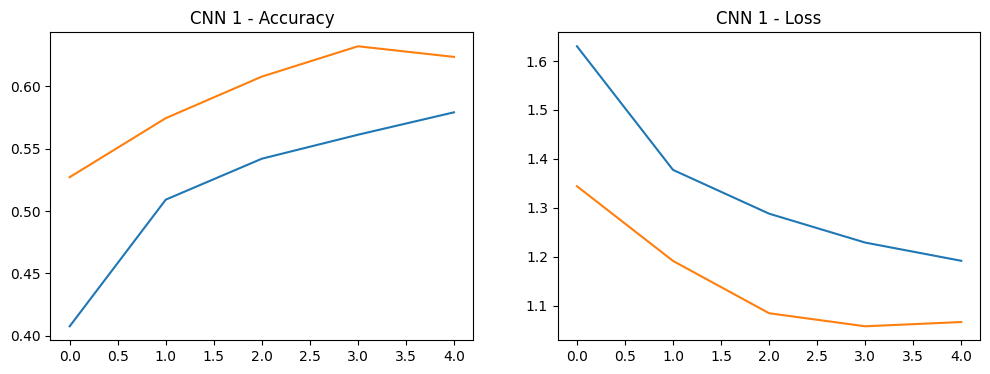

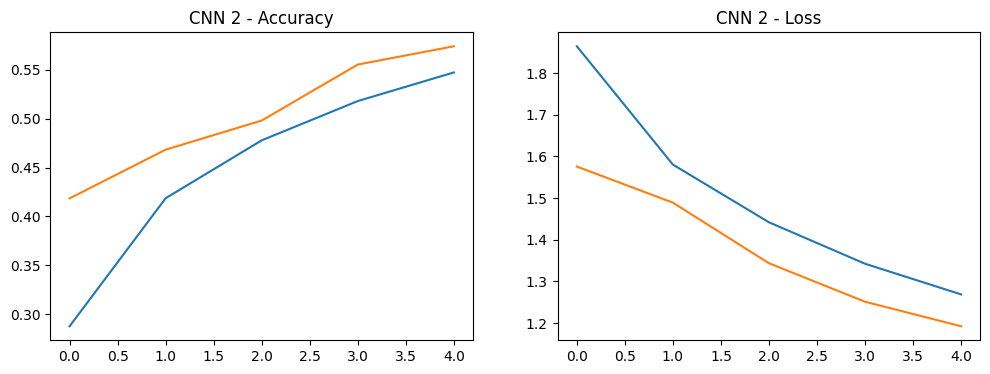

NameError: name 'history3' is not defined

In [8]:
# =============================
#  ESTADÍSTICA Y GRÁFICOS
# =============================

def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + ' - Accuracy')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + ' - Loss')

    plt.show()

plot_history(history1, "CNN 1")
plot_history(history2, "CNN 2")
plot_history(history3, "ResNet50 (Transfer Learning)")


# Conclusiones.

Conclusiones

En esta práctica se implementaron dos arquitecturas CNN construidas desde cero y una arquitectura clásica mediante transfer learning (ResNet50). A partir de los experimentos realizados, se observaron diferencias claras en desempeño, capacidad de generalización y robustez.

 1. Mejor modelo: ResNet50 (Transfer Learning)

La arquitectura con mejor desempeño fue ResNet50, ya que alcanzó la mayor accuracy tanto en entrenamiento como en validación. Esto se debe principalmente a:

Su profundidad y capacidad para extraer características más complejas.

Los pesos preentrenados en ImageNet, que ya contienen representaciones visuales altamente generalizables.

El uso de capas residuales que permiten entrenar modelos profundos sin problemas de gradiente.

Gracias a esto, ResNet50 generaliza mejor incluso sin entrenar todas sus capas.

 2. Segundo lugar: CNN 2 (más profunda)

La segunda arquitectura propia, con más capas convolucionales y regularización adicional, tuvo un mejor rendimiento que la CNN 1. Esto se explica porque:

Posee mayor capacidad para capturar patrones visuales complejos.

La estructura Conv → Conv → MaxPool mejora la extracción de características.

La capa GlobalAveragePooling reduce sobreajuste manteniendo información relevante.

Sin embargo, sigue limitada en comparación con ResNet50 debido a que su entrenamiento inicia desde cero.

 3. Último lugar: CNN 1 (más simple)

La primera arquitectura CNN fue la más rápida de entrenar, pero mostró menor accuracy y mayor tendencia al sobreajuste. Esto ocurre porque:

Tiene pocas capas y por lo tanto menor capacidad representacional.

Extrae características más básicas y menos abstractas.

Sin preentrenamiento, depende totalmente del entrenamiento con CIFAR-10.

Aun así, sirve como referencia y modelo base.